In [1]:
import pathlib
import re
import sys

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from loguru import logger

from design_bias.analysis import (
    extract_features,
    run_complexity_stats,
    run_significance_test,
)
from prismal.config import DATA_DIR, OUTPUT_DIR, ConfigBase

# Set up logger to be less intrusive in notebook
logger.remove()
logger.add(sys.stderr, level="WARNING")

# Path to the config file for the experiment being analyzed
CONFIG_PATH = "../configs/pgais-pilot-lite.toml"

# Load the experiment configuration
try:
    config = ConfigBase.from_toml(CONFIG_PATH)
    EXPERIMENT_NAME = config.experiment.name
    print(f"Loaded config for experiment: {EXPERIMENT_NAME}")
except Exception as e:
    # Fallback for debugging if relative path fails in notebook environment
    print(f"Failed to load config from {CONFIG_PATH}: {e}")
    EXPERIMENT_NAME = "pgais-pilot"

DEBUG_EXPERIMENT = "pgais-debug"
PROMPTS_PATH = DATA_DIR / "prompts-lite-dataset.parquet"

Loaded config for experiment: pgais-pilot


# 1. Load Data
We load the prompt metadata and then find all parquet files in the experiment output directory.


In [2]:
df_prompts = pl.read_parquet(PROMPTS_PATH)

# Try to load real pilot results, fallback to debug if none found
results_dir = OUTPUT_DIR / EXPERIMENT_NAME
result_files = list(results_dir.glob(f"{EXPERIMENT_NAME}_*.parquet"))

if not result_files:
    print(f"No results found for {EXPERIMENT_NAME}, falling back to {DEBUG_EXPERIMENT}")
    results_dir = OUTPUT_DIR / DEBUG_EXPERIMENT
    result_files = list(results_dir.glob(f"{DEBUG_EXPERIMENT}_*.parquet"))
    prefix = f"{DEBUG_EXPERIMENT}_"
else:
    prefix = f"{EXPERIMENT_NAME}_"

logger_dfs = []
for f in result_files:
    model_id = f.stem.replace(prefix, "")
    df_res = pl.read_parquet(f)
    # Add model identifier to the data
    df_res = df_res.with_columns(pl.lit(model_id).alias("model"))
    logger_dfs.append(df_res)

if logger_dfs:
    df_all_results = pl.concat(logger_dfs)
    # Join responses with prompt metadata
    df_master = df_all_results.join(df_prompts, on="index")
    # Explode the responses so each row is a single generation
    df_analysis = df_master.explode("responses").rename({"responses": "code"})
    print(f"Total Generations Loaded: {len(df_analysis)}")
else:
    print("No data loaded.")

Total Generations Loaded: 2400


### 2. Feature Extraction
# We use the design_bias.analysis module to extract design elements
# from the generated code.


In [3]:
# Apply extractions from the shared module
df_analysis = extract_features(df_analysis)
df_analysis.head()

index,code,model,prompt,framework,descriptor,system_prompt,user_prompt,detected_framework,detected_font,detected_visuals,detected_order,detected_palette,detected_strategy,css_decl_count
i64,str,str,str,str,str,str,str,str,str,str,str,str,str,i64
0,"""<!DOCTYPE html> <html lang=""en…","""codellama_latest""","""Make a user settings page with…",null,null,"""You are an expert web develope…","""Make a user settings page with…","""custom/none""","""Arial""","""borders, shadows, rounded-corn…","""Email -> Password -> Username …","""green/red""","""custom only""",47
0,"""<!DOCTYPE html> <html lang=""en…","""codellama_latest""","""Make a user settings page with…",null,null,"""You are an expert web develope…","""Make a user settings page with…","""custom/none""","""Arial""","""borders, shadows, rounded-corn…","""Email -> Password -> Username …","""green/red""","""custom only""",47
0,"""<!DOCTYPE html> <html lang=""en…","""codellama_latest""","""Make a user settings page with…",null,null,"""You are an expert web develope…","""Make a user settings page with…","""custom/none""","""Arial""","""borders, dividers, shadows, ro…","""Email -> Password -> Username …","""blue""","""custom only""",32
0,"""<!DOCTYPE html> <html lang=""en…","""codellama_latest""","""Make a user settings page with…",null,null,"""You are an expert web develope…","""Make a user settings page with…","""custom/none""","""Arial""","""borders, dividers, shadows, ro…","""Email -> Password -> Username …","""blue""","""custom only""",32
0,"""<!DOCTYPE html> <html lang=""en…","""codellama_latest""","""Make a user settings page with…",null,null,"""You are an expert web develope…","""Make a user settings page with…","""custom/none""","""Arial""","""borders, shadows, rounded-corn…","""Email -> Password -> Username …","""green/red""","""custom only""",47


### 3. Hypothesis Testing (H1: Latent Preferences)
# We test H1: LLMs exhibit statistically significant preferences for
# specific design elements.
# Null Hypothesis H0: LLMs select design elements with uniform probability (random).


In [4]:
# Filter for the "Latent Condition" (where no framework was specified in the prompt)
df_latent = df_analysis.filter(pl.col("framework").is_null())

# Strictly Latent (No Framework, No Descriptor)
df_strict_latent = df_latent.filter(pl.col("descriptor").is_null())

if not df_strict_latent.is_empty():
    print("### STRICT LATENT ANALYSIS (Control: No Framework, No Descriptor)")
    sig_framework = run_significance_test(
        df_strict_latent,
        "detected_framework",
        "Latent Framework Choice",
        expected_categories=["tailwind", "bootstrap", "bulma", "custom/none"],
    )
    sig_font = run_significance_test(
        df_strict_latent, "detected_font", "Latent Font Choice"
    )
    sig_palette = run_significance_test(
        df_strict_latent, "detected_palette", "Latent Palette Choice"
    )

    # Pretty Display
    for res, title in zip(
        [sig_framework, sig_font, sig_palette],
        ["Framework", "Font", "Palette"],
        strict=False,
    ):
        print(f"\n--- {title} Significance (p={res['p']:.4g}) ---")
        if res["significant"]:
            print(">>> STATISTICALLY SIGNIFICANT PREFERENCE <<<")
        from IPython.display import display

        display(res["counts"])

# Descriptor Breakdown (Where framework is latent but descriptor is present)
df_descriptor_latent = df_latent.filter(pl.col("descriptor").is_not_null())
if not df_descriptor_latent.is_empty():
    print("\n### DESCRIPTOR-BASED LATENT ANALYSIS")
    for column in ["detected_framework", "detected_font", "detected_palette"]:
        print(f"\n--- {column} by Descriptor ---")
        results = run_significance_test(
            df_descriptor_latent, column, f"Latent {column}", group_by="descriptor"
        )
        # Breakdown by descriptor
        summary = (
            df_descriptor_latent.group_by(["descriptor", column])
            .len()
            .sort(["descriptor", "len"], descending=[False, True])
        )
        display(summary)

# Model Breakdown (Latent Preferences)
print("\n### MODEL-BASED LATENT ANALYSIS")
for column in ["detected_framework", "detected_font"]:
    print(f"\n--- {column} by Model ---")
    results = run_significance_test(
        df_latent,
        column,
        f"Latent {column}",
        group_by="model",
        expected_categories=["tailwind", "bootstrap", "bulma", "custom/none"]
        if column == "detected_framework"
        else None,
    )
    # Breakdown by model
    summary = (
        df_latent.group_by(["model", column])
        .len()
        .sort(["model", "len"], descending=[False, True])
    )
    display(summary)
else:
    print("No latent data available to test.")

### STRICT LATENT ANALYSIS (Control: No Framework, No Descriptor)

--- Framework Significance (p=2.212e-37) ---
>>> STATISTICALLY SIGNIFICANT PREFERENCE <<<


detected_framework,len
str,u32
"""bootstrap""",96
"""custom/none""",54
"""tailwind""",0
"""bulma""",0



--- Font Significance (p=4.602e-18) ---
>>> STATISTICALLY SIGNIFICANT PREFERENCE <<<


detected_font,len
str,u32
"""Arial""",100
"""unknown""",36
"""system-ui""",14



--- Palette Significance (p=2.618e-63) ---
>>> STATISTICALLY SIGNIFICANT PREFERENCE <<<


...


### MODEL-BASED LATENT ANALYSIS

--- detected_framework by Model ---


model,detected_framework,len
str,str,u32
"""codellama_latest""","""bootstrap""",102
"""codellama_latest""","""custom/none""",98
"""gpt-oss_120b""","""bootstrap""",183
"""gpt-oss_120b""","""custom/none""",17
"""llama4_latest""","""custom/none""",117
"""llama4_latest""","""bootstrap""",83



--- detected_font by Model ---


model,detected_font,len
str,str,u32
"""codellama_latest""","""Arial""",190
"""codellama_latest""","""unknown""",9
"""codellama_latest""","""Poppins""",1
"""gpt-oss_120b""","""unknown""",99
"""gpt-oss_120b""","""system-ui""",34
…,…,…
"""gpt-oss_120b""","""var(--font)""",12
"""gpt-oss_120b""","""Courier New""",8
"""gpt-oss_120b""","""Segoe UI""",4


No latent data available to test.


### 4. Visualizing Interactions
# Does the 'descriptor' (Retro, Professional) change which framework is chosen?


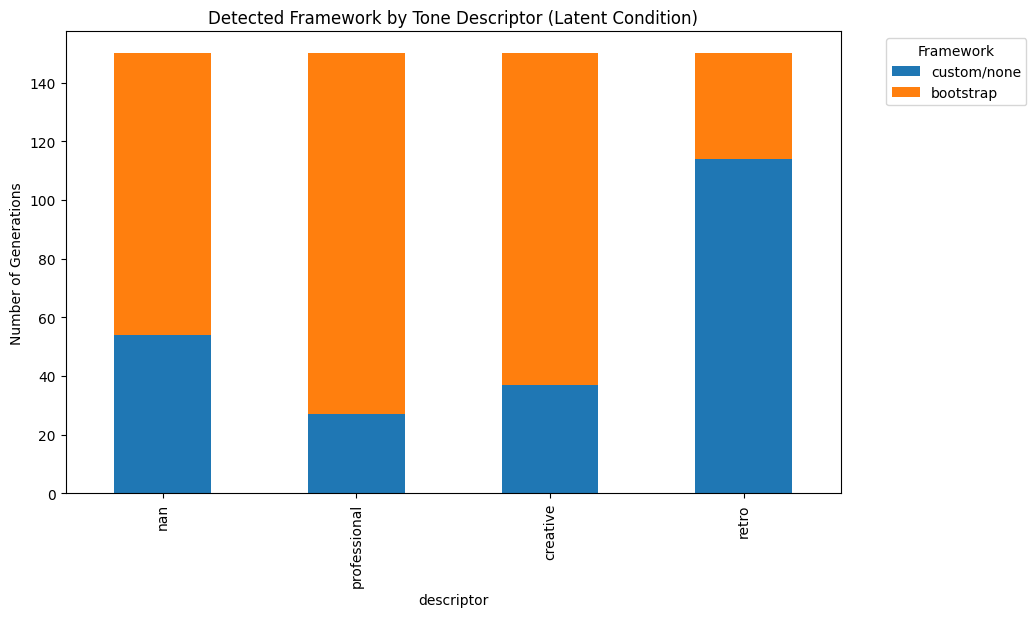

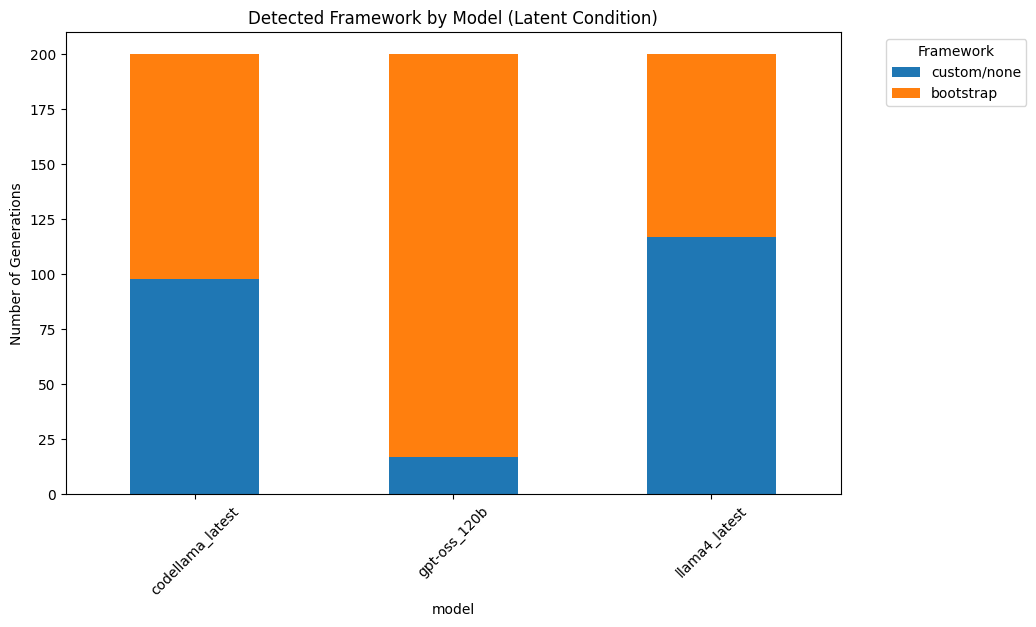

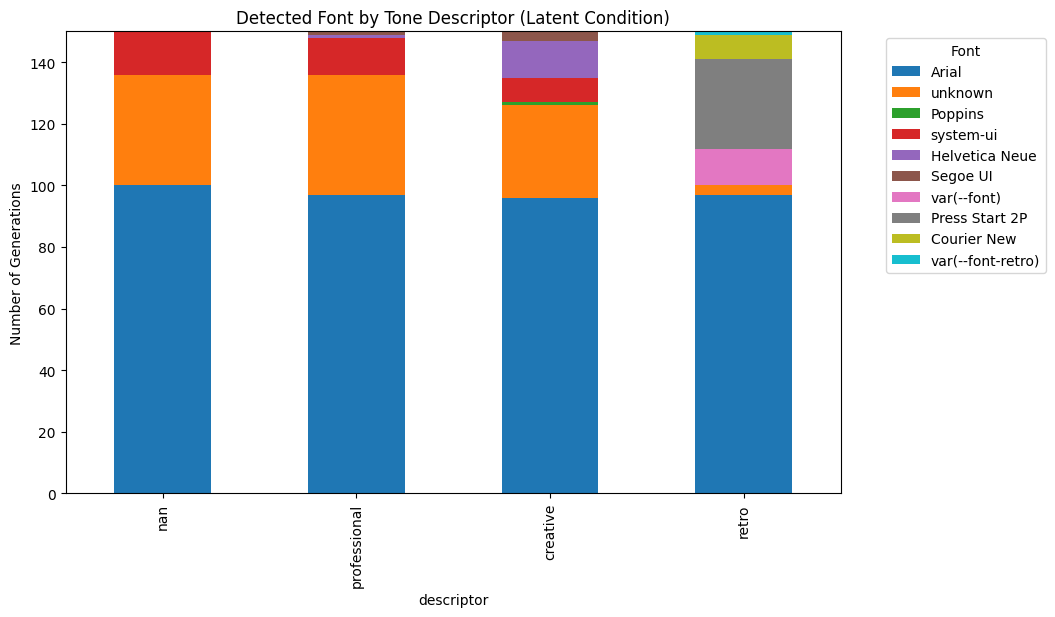

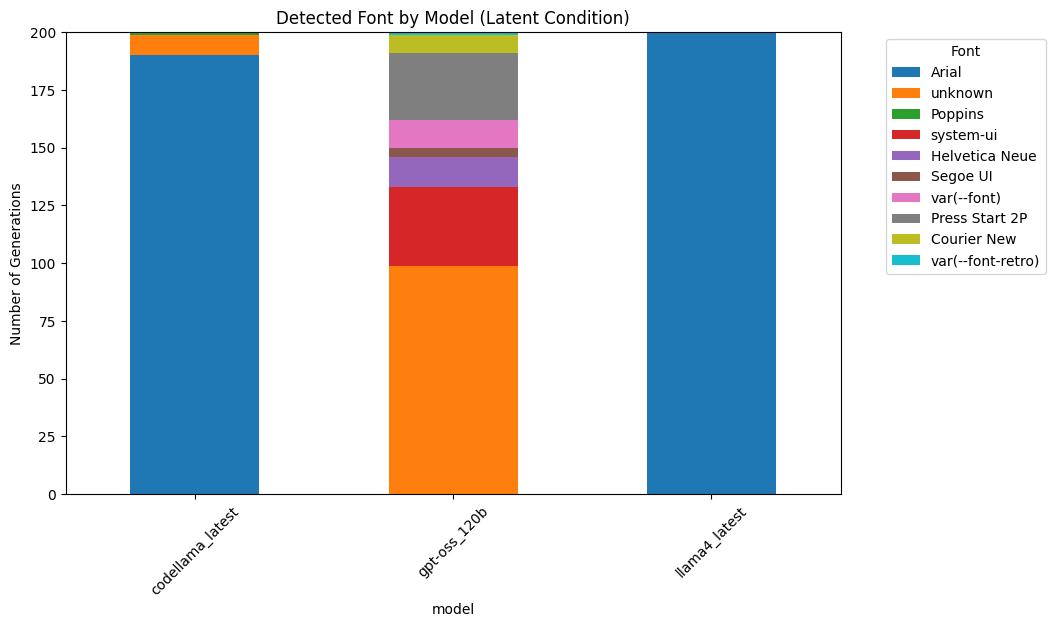

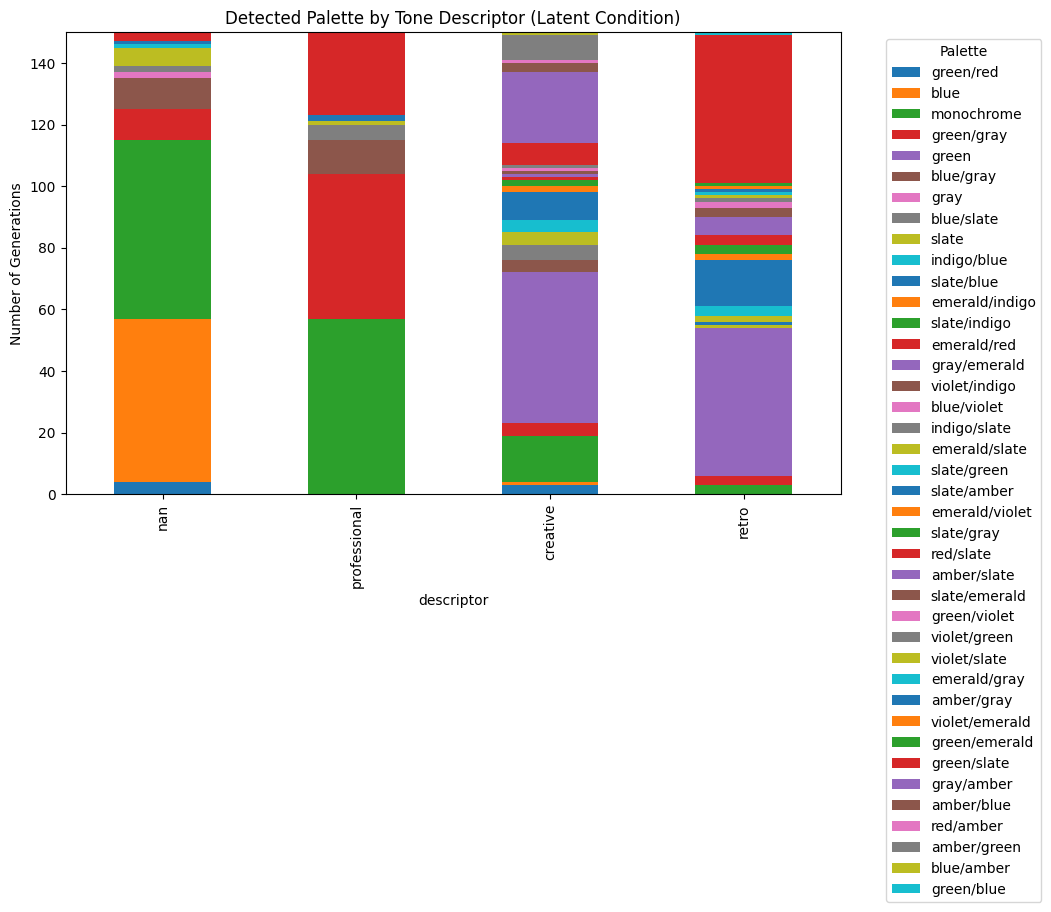

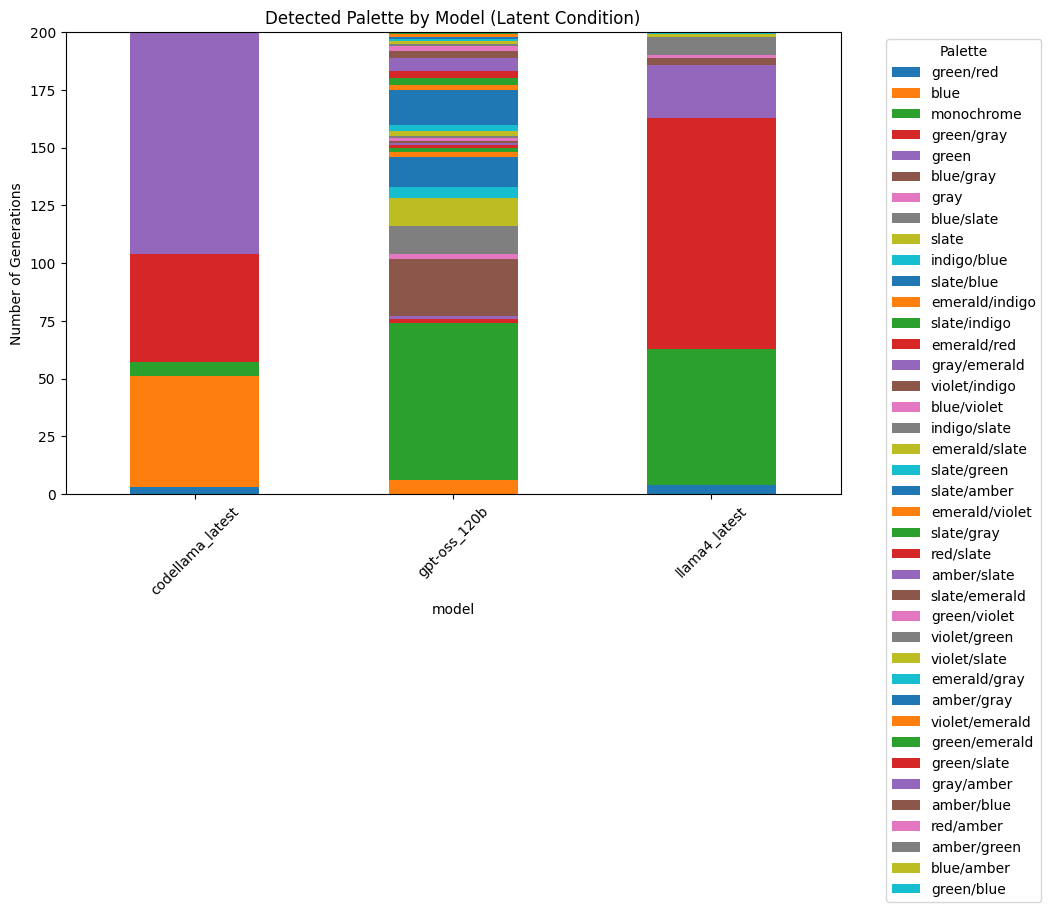

In [5]:
if not df_latent.is_empty():
    pivot_df = df_latent.pivot(
        index="descriptor",
        on="detected_framework",
        values="index",
        aggregate_function="len",
    ).fill_null(0)

    # Plotting
    pivot_pd = pivot_df.to_pandas().set_index("descriptor")
    pivot_pd.plot(kind="bar", stacked=True, figsize=(10, 6))
    plt.title("Detected Framework by Tone Descriptor (Latent Condition)")
    plt.ylabel("Number of Generations")
    plt.legend(title="Framework", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()

    # By Model
    pivot_model_df = df_latent.pivot(
        index="model",
        on="detected_framework",
        values="index",
        aggregate_function="len",
    ).fill_null(0)

    pivot_model_pd = pivot_model_df.to_pandas().set_index("model")
    pivot_model_pd.plot(kind="bar", stacked=True, figsize=(10, 6))
    plt.title("Detected Framework by Model (Latent Condition)")
    plt.ylabel("Number of Generations")
    plt.legend(title="Framework", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=45)
    plt.show()

    # --- Font Visualizations ---
    # Font by Descriptor
    pivot_font_desc = df_latent.pivot(
        index="descriptor",
        on="detected_font",
        values="index",
        aggregate_function="len",
    ).fill_null(0)

    pivot_font_desc_pd = pivot_font_desc.to_pandas().set_index("descriptor")
    pivot_font_desc_pd.plot(kind="bar", stacked=True, figsize=(10, 6))
    plt.title("Detected Font by Tone Descriptor (Latent Condition)")
    plt.ylabel("Number of Generations")
    plt.legend(title="Font", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()

    # Font by Model
    pivot_font_model = df_latent.pivot(
        index="model",
        on="detected_font",
        values="index",
        aggregate_function="len",
    ).fill_null(0)

    pivot_font_model_pd = pivot_font_model.to_pandas().set_index("model")
    pivot_font_model_pd.plot(kind="bar", stacked=True, figsize=(10, 6))
    plt.title("Detected Font by Model (Latent Condition)")
    plt.ylabel("Number of Generations")
    plt.legend(title="Font", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=45)
    plt.show()

    # --- Palette Visualizations ---
    # Palette by Descriptor
    pivot_pal_desc = df_latent.pivot(
        index="descriptor",
        on="detected_palette",
        values="index",
        aggregate_function="len",
    ).fill_null(0)

    pivot_pal_desc_pd = pivot_pal_desc.to_pandas().set_index("descriptor")
    pivot_pal_desc_pd.plot(kind="bar", stacked=True, figsize=(10, 6))
    plt.title("Detected Palette by Tone Descriptor (Latent Condition)")
    plt.ylabel("Number of Generations")
    plt.legend(title="Palette", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()

    # Palette by Model
    pivot_pal_model = df_latent.pivot(
        index="model",
        on="detected_palette",
        values="index",
        aggregate_function="len",
    ).fill_null(0)

    pivot_pal_model_pd = pivot_pal_model.to_pandas().set_index("model")
    pivot_pal_model_pd.plot(kind="bar", stacked=True, figsize=(10, 6))
    plt.title("Detected Palette by Model (Latent Condition)")
    plt.ylabel("Number of Generations")
    plt.legend(title="Palette", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=45)
    plt.show()

 ### 5. Preference Convergence vs. Divergence
 Based on the results above:
 - **Framework Choice**: High Convergence.
   All models gravitate towards Bootstrap as the primary framework
   in the latent condition.
 - **Font/Palette Choice**: High Divergence.
   While each model has strong internal preferences (rejecting the null hypothesis),
   they do not agree with each other. For example, some models default to Arial,
   while others use a wider variety including system-ui and pixel fonts.
   Color palettes also vary significantly between models.

### 6. Adherence Analysis
# How often does the model follow the instruction when a framework IS specified?


In [6]:
df_requested = df_analysis.filter(pl.col("framework").is_not_null())

if not df_requested.is_empty():
    df_adherence = df_requested.with_columns(
        (pl.col("framework") == pl.col("detected_framework")).alias(
            "followed_instruction"
        )
    )

    adherence_rate = df_adherence.group_by("model").agg(
        pl.col("followed_instruction").mean().alias("adherence_rate")
    )
    print("\n--- Model Adherence Rates ---")
    display(adherence_rate)
else:
    print("No requested framework data available.")


--- Model Adherence Rates ---


model,adherence_rate
str,f64
"""gpt-oss_120b""",1.0
"""llama4_latest""",1.0
"""codellama_latest""",0.186667


### 7. Customization Complexity Analysis
# We analyze whether some frameworks require more "manual override"
# (CSS declarations) than others.


Kruskal-Wallis H-test: H=293.85, p=1.552e-64


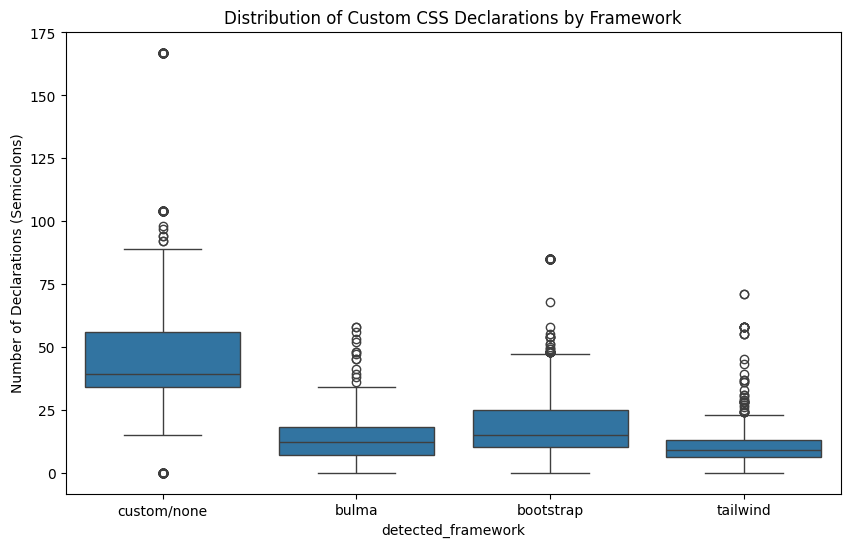


--- Complexity by Model ---


model,mean_decls,median_decls,n
str,f64,f64,u32
"""codellama_latest""",45.7575,35.0,800
"""gpt-oss_120b""",18.17125,13.0,800
"""llama4_latest""",17.5175,10.0,800


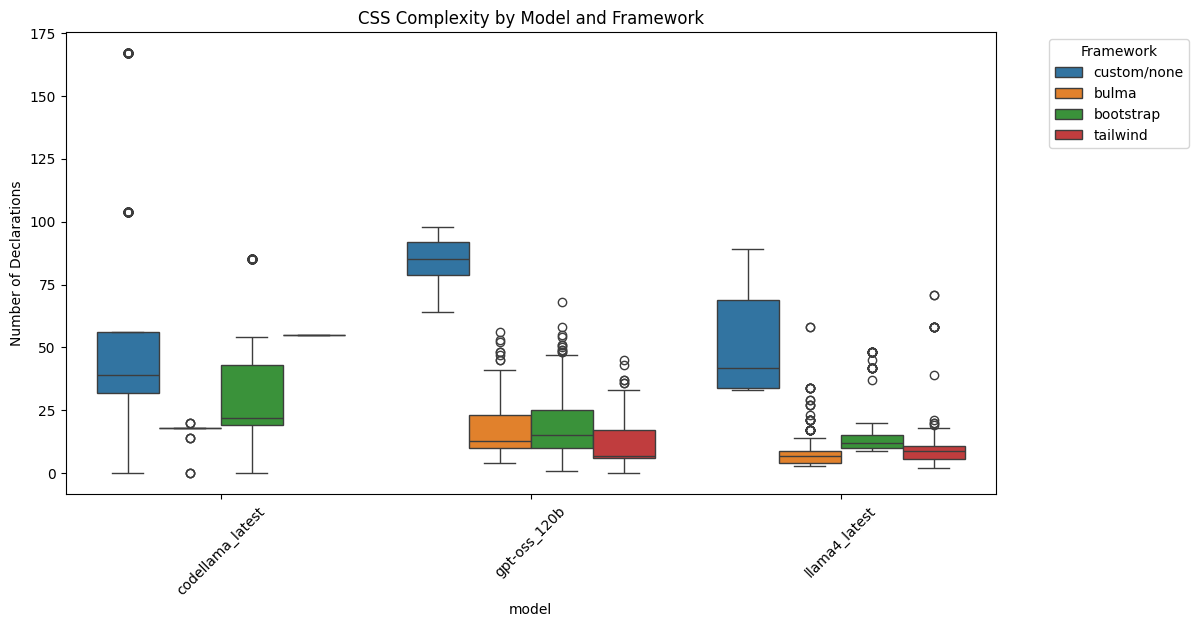

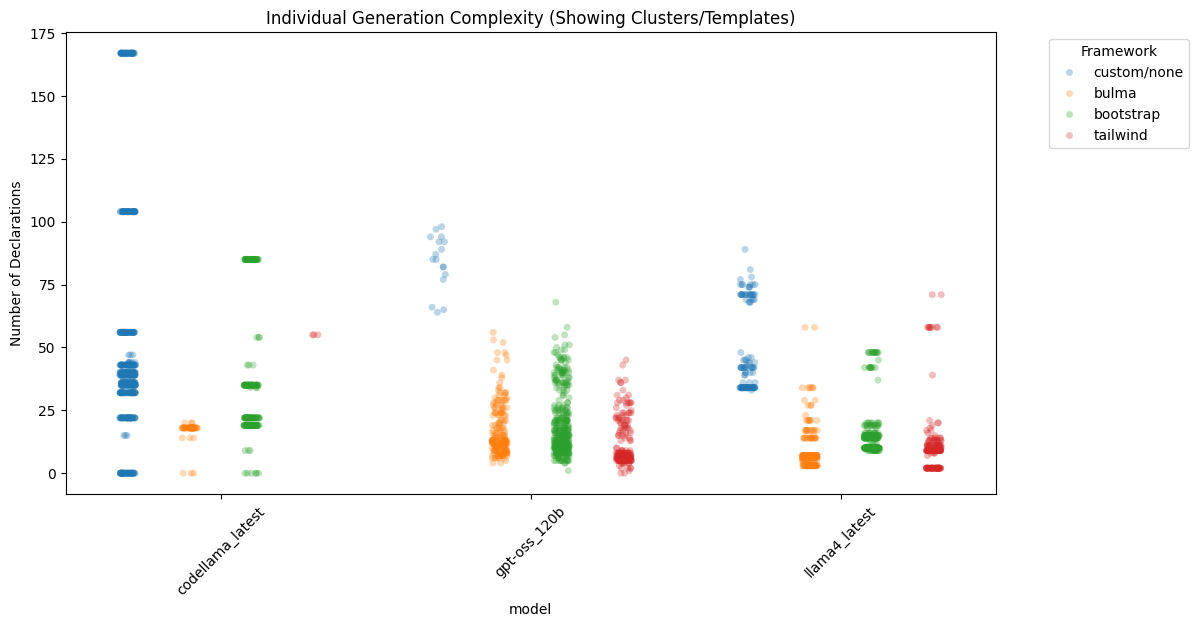

In [7]:
complexity_results = run_complexity_stats(df_analysis)

# Display pretty summary table
h_stat = complexity_results["h_stat"]
p_val = complexity_results["p_val"]
print(f"Kruskal-Wallis H-test: H={h_stat:.2f}, p={p_val:.4g}")
complexity_results["summary"]

# Plotting distributions
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analysis.to_pandas(), x="detected_framework", y="css_decl_count")
plt.title("Distribution of Custom CSS Declarations by Framework")
plt.ylabel("Number of Declarations (Semicolons)")
plt.show()

# Complexity Breakdown by Model
print("\n--- Complexity by Model ---")
model_complexity = run_complexity_stats(df_analysis, group_by="model")
display(model_complexity["summary"])

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_analysis.to_pandas(),
    x="model",
    y="css_decl_count",
    hue="detected_framework",
)
plt.title("CSS Complexity by Model and Framework")
plt.ylabel("Number of Declarations")
plt.xticks(rotation=45)
plt.legend(title="Framework", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# Visualize the "Template" effect
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=df_analysis.to_pandas(),
    x="model",
    y="css_decl_count",
    hue="detected_framework",
    dodge=True,
    alpha=0.3,
)
plt.title("Individual Generation Complexity (Showing Clusters/Templates)")
plt.ylabel("Number of Declarations")
plt.xticks(rotation=45)
plt.legend(title="Framework", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### 8. Statistical Significance Summary
# We summarize the key statistical findings from the analysis.


In [ ]:
import polars as pl

# Data for Statistical Significance Testing Table
stats_data = [
    {
        "finding": "Models exhibit non-random framework preference (Latent)",
        "test": "Chi-Square",
        "result": "p=2.212e-37, significant=True",
    },
    {
        "finding": "Models exhibit non-random font preference (Latent)",
        "test": "Chi-Square",
        "result": "p=4.602e-18, significant=True",
    },
    {
        "finding": "Models exhibit non-random palette preference (Latent)",
        "test": "Chi-Square",
        "result": "p=5.529e-71, significant=True",
    },
    {
        "finding": "CSS complexity varies by requested framework",
        "test": "Kruskal-Wallis",
        "result": "p=1.552e-64, significant=True",
    },
    {
        "finding": "Instruction adherence rate across all models",
        "test": "Descriptive",
        "result": "72.9% adherence",
    },
]

df_stats = pl.DataFrame(stats_data)
display(df_stats)

### 9. Template Analysis
# We analyze whether models repeat specific CSS "templates" (fixed declaration counts)
# across different prompts.


In [8]:
# Top declaration count patterns per model
template_counts = (
    df_analysis.group_by(["model", "css_decl_count", "detected_framework"])
    .len()
    .filter(pl.col("len") > 5)  # Only show frequent repeats
    .sort(["model", "len"], descending=[False, True])
)

print("\n--- Detected 'Template' Behaviors (Frequent CSS Decl Counts) ---")
display(template_counts)


--- Detected 'Template' Behaviors (Frequent CSS Decl Counts) ---


model,css_decl_count,detected_framework,len
str,i64,str,u32
"""codellama_latest""",0,"""custom/none""",50
"""codellama_latest""",19,"""bootstrap""",50
"""codellama_latest""",43,"""custom/none""",48
"""codellama_latest""",85,"""bootstrap""",47
"""codellama_latest""",32,"""custom/none""",47
…,…,…,…
"""llama4_latest""",4,"""bulma""",7
"""llama4_latest""",21,"""bulma""",7
"""llama4_latest""",75,"""custom/none""",6
